In [1]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import os

In [2]:
dir = r"..\TOPAS_data\do_field\Dose"
list = os.listdir(dir)

topas_dose = pd.DataFrame(columns=['Depth', 'Dose'])
for file in list:
    newrow = {}
    newrow['Depth'] = float(os.path.splitext(file)[0])
    newrow['Dose'] = pd.read_csv(os.path.join(dir,file), skiprows=5, header=None).iloc[0][0]

    newrow = pd.DataFrame([newrow])
    topas_dose = pd.concat([topas_dose, newrow], ignore_index=True)

#normalise dose
topas_dose['Dose_norm'] = topas_dose['Dose']/max(topas_dose['Dose'])

C:\Users\linux\AppData\Local\Temp\ipykernel_34500\2766935298.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  topas_dose = pd.concat([topas_dose, newrow], ignore_index=True)


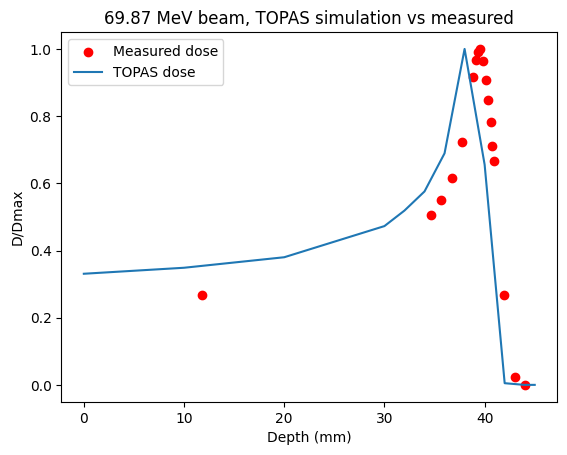

In [3]:
data = pd.read_excel(r"../Mid LET calculation/BP 69.87 measured - copy for scripts.xlsx")

BP_measured = pd.DataFrame()
BP_measured['Depth'] = data['Depth (mm)']
BP_measured['Dose'] = data['Dose (Gy)']/np.max(data['Dose (Gy)'])

plt.scatter(BP_measured['Depth'], BP_measured['Dose'], label='Measured dose', color='r')
plt.plot(topas_dose['Depth'], topas_dose['Dose_norm'], label = 'TOPAS dose')
plt.title('69.87 MeV beam, TOPAS simulation vs measured')
plt.xlabel('Depth (mm)')
plt.ylabel('D/Dmax')
plt.legend()

In [4]:
dir = r"..\TOPAS_data\do_field\LET"
list = os.listdir(dir)

topas_let = pd.DataFrame(columns=['Depth', 'LET'])
for file in list:
    newrow = {}
    newrow['Depth'] = float(os.path.splitext(file)[0])
    newrow['LET'] = pd.read_csv(os.path.join(dir,file), skiprows=5, header=None).iloc[0][0]

    if newrow['LET'] !='# The value of the combined scorer for those voxels/bins has been set to 0.':
        newrow = pd.DataFrame([newrow])
        topas_let = pd.concat([topas_let, newrow], ignore_index=True)

print(topas_let)

   Depth        LET
0    0.0   4.610901
1   10.0  10.092726
2   20.0   9.445855
3   30.0   8.198993
4   32.0   7.729670
5   34.0   7.770522
6   36.0   7.751786
7   38.0   8.339307
8   40.0  11.078153
9   42.0   9.667996


C:\Users\linux\AppData\Local\Temp\ipykernel_34500\3535185529.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  topas_let = pd.concat([topas_let, newrow], ignore_index=True)


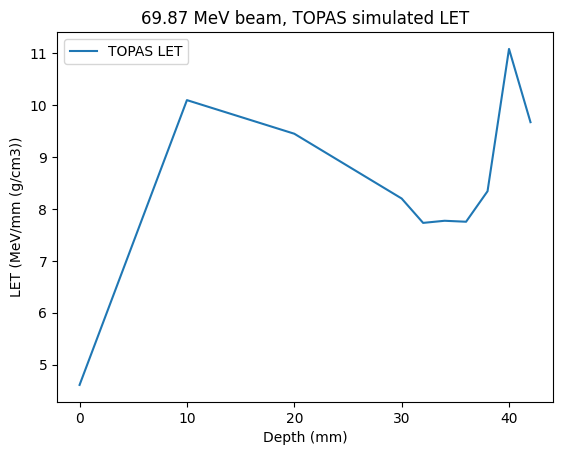

In [5]:
plt.plot(topas_let['Depth'], topas_let['LET'], label = 'TOPAS LET')
plt.title('69.87 MeV beam, TOPAS simulated LET')
plt.xlabel('Depth (mm)')
plt.ylabel('LET (MeV/mm (g/cm3))')
plt.legend()